# build_sequences_bulk sanity check

Goal: verify the new bulk pipeline (`src/build_sequences_bulk.py`) is equivalent to the old `build_sequences.py`, and diagnose why early sectors (1-20) yield 0 sequences.

## Tests
1. **Differential test**: pick a TIC where the OLD pipeline produced .npz output; download with both lightkurve and my `read_fits`; confirm flux/time arrays match.
2. **Segment yield**: run the new segmentation logic on the same data, verify segment list is identical.
3. **Sector sweep**: plot lightcurves + NaN runs + segment-length distribution for one TIC per sector in {1, 10, 21, 27, 38, 65}. Confirms early-sector 0-yield is a data-quality artifact, not a bug.
4. **Visual confirmation**: plot Class-A windows for a successful TIC.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import requests
import re
import lightkurve as lk

# Import the bulk pipeline functions
from build_sequences_bulk import (
    read_fits as bulk_read_fits,
    find_segments,
    mad_normalize,
    slide_windows,
    classify_window,
    longest_nan_run,
    SHORT_NAN_RUN,
)

REPO = pathlib.Path.cwd().parent.parent
DATA_TEMP = REPO / 'data' / 'fits_temp'
DATA_TEMP.mkdir(parents=True, exist_ok=True)
print(f'Repo: {REPO}')
print(f'FITS temp: {DATA_TEMP}')

Repo: C:\git_repo\Stellar-World-Model
FITS temp: C:\git_repo\Stellar-World-Model\data\fits_temp


C:\Users\user1\miniconda3\envs\astro\lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Helpers

In [2]:
def url_for(tic_id: int, sector: int) -> str | None:
    """Look up the FITS URL for (tic_id, sector) from the cached curl script."""
    path = REPO / 'data' / 'curl_scripts' / f'tesscurl_sector_{sector}_lc.sh'
    if not path.exists():
        # Fetch it
        u = f'https://archive.stsci.edu/missions/tess/download_scripts/sector/tesscurl_sector_{sector}_lc.sh'
        r = requests.get(u, timeout=60)
        r.raise_for_status()
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(r.text, encoding='utf-8')
    pad = f'{tic_id:016d}'
    for line in path.read_text(encoding='utf-8').splitlines():
        if pad in line and line.startswith('curl'):
            parts = line.split()
            return parts[-1]
    return None

def download_fits(url: str, dest: pathlib.Path) -> pathlib.Path:
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    r = requests.get(url, stream=True, timeout=180)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(1 << 16):
            f.write(chunk)
    return dest

## Test 1 — Differential: lightkurve vs my read_fits

Pick TIC 395011859 sector 38 (the old pipeline produced 1 .npz file for it).

In [3]:
TIC_DIFF, SEC_DIFF = 395011859, 38

# Path A: my read_fits (download direct) — INCLUDES the time-gap guard
url = url_for(TIC_DIFF, SEC_DIFF)
print(f'URL: {url}')
fits_path = DATA_TEMP / f'diff_TIC{TIC_DIFF}_s{SEC_DIFF}.fits'
download_fits(url, fits_path)
time_a, flux_a = bulk_read_fits(fits_path)
print(f'read_fits (with gap-guard):   {len(flux_a)} cadences, {np.isnan(flux_a).sum()} NaN')

# Path B: lightkurve as ground-truth oracle for row-filter + quality mask ONLY
#   lightkurve does NOT inject NaN at time gaps — see docs/adr/0003-segment-on-time-gap.md
def get_col(lc, *names):
    low = {c.lower(): c for c in lc.colnames}
    for n in names:
        if n.lower() in low:
            return lc[low[n.lower()]]
    raise KeyError(f'None of {names} in {lc.colnames}')

sr = lk.search_lightcurve(f'TIC {TIC_DIFF}', mission='TESS', author='SPOC', exptime=120, sector=SEC_DIFF)
lc = sr.download(quality_bitmask='none')
print('  lc.colnames (first 8):', lc.colnames[:8])
flux_b = np.asarray(get_col(lc, 'PDCSAP_FLUX', 'pdcsap_flux').value, dtype=np.float32)
quality_b = np.asarray(get_col(lc, 'QUALITY', 'quality').value)
flux_b[quality_b != 0] = np.nan
time_b = np.asarray(lc.time.value, dtype=np.float32)
print(f'lightkurve (no gap-guard):    {len(flux_b)} cadences, {np.isnan(flux_b).sum()} NaN')

# A1: array length matches (NaN-TIME drop is identical)
assert len(flux_a) == len(flux_b), f'Length mismatch: {len(flux_a)} vs {len(flux_b)}'

# A2: lightkurve's NaN positions are a SUBSET of read_fits's NaN positions.
#     gap-guard only ADDS NaN — never removes one.
nan_lk = np.isnan(flux_b)
nan_my = np.isnan(flux_a)
removed_by_us = int((nan_lk & ~nan_my).sum())
print(f'lightkurve NaN positions removed/changed by read_fits: {removed_by_us}  (expect 0)')
assert removed_by_us == 0, 'BUG: gap-guard removed/changed a lightkurve NaN position'

# A3: every position the gap-guard targets must be NaN in flux_a.
#     (Some may have ALREADY been NaN from quality masking — that's fine, it just means
#      the gap-guard is redundant for that gap, not that it failed.)
from build_sequences_bulk import _TIME_GAP_MULTIPLIER
diffs = np.diff(time_a)
median_diff = float(np.median(diffs))
gap_mask = np.concatenate([[False], diffs > _TIME_GAP_MULTIPLIER * median_diff])
expected_gaps = int(gap_mask.sum())
gap_positions_are_nan = bool(np.isnan(flux_a[gap_mask]).all()) if expected_gaps else True
gap_overlap_with_quality = int((gap_mask & nan_lk).sum())
extra_new = int((nan_my & ~nan_lk).sum())
print(f'Gaps detected by gap-guard (diff > {_TIME_GAP_MULTIPLIER}x median={median_diff:.6f}): {expected_gaps}')
print(f'  -- of which overlap with quality-mask NaN:           {gap_overlap_with_quality}')
print(f'  -- of which are NEW NaN positions (not in lightkurve): {extra_new}')
assert gap_positions_are_nan, 'BUG: gap-guard targets are not NaN in flux_a'
assert extra_new + gap_overlap_with_quality == expected_gaps, \
    f'BUG: extra_new({extra_new}) + overlap({gap_overlap_with_quality}) != gaps({expected_gaps})'

# A4: non-NaN values match byte-for-byte on commonly-valid cadences
both_valid = ~(nan_my | nan_lk)
max_diff = float(np.abs(flux_a[both_valid] - flux_b[both_valid]).max()) if both_valid.any() else 0.0
print(f'Max abs diff on commonly-valid cadences: {max_diff:.6f}')
assert max_diff < 1e-3, f'BUG: flux values differ by {max_diff}'

print(f'PASS: read_fits == lightkurve_NaN positions ⊆ read_fits_NaN, all {expected_gaps} gap positions are NaN')

URL: https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:TESS/product/tess2021118034608-s0038-0000000395011859-0209-s_lc.fits
read_fits (with gap-guard):   18535 cadences, 44 NaN


  lc.colnames (first 8): ['time', 'flux', 'flux_err', 'timecorr', 'cadenceno', 'centroid_col', 'centroid_row', 'sap_flux']
lightkurve (no gap-guard):    18535 cadences, 44 NaN
lightkurve NaN positions removed/changed by read_fits: 0  (expect 0)
Gaps detected by gap-guard (diff > 5x median=0.001465): 1
  -- of which overlap with quality-mask NaN:           1
  -- of which are NEW NaN positions (not in lightkurve): 0
Max abs diff on commonly-valid cadences: 0.000000
PASS: read_fits == lightkurve_NaN positions ⊆ read_fits_NaN, all 1 gap positions are NaN


## Test 2 — Segment list equivalence

Run `find_segments` on both flux arrays. They should produce identical segment lists.

In [4]:
segs_a = find_segments(flux_a, gap_threshold=1)
segs_b_raw = find_segments(flux_b, gap_threshold=1)  # lightkurve flux WITHOUT gap-guard
print(f'Segments — read_fits (with gap-guard):  {len(segs_a)}')
print(f'         — lightkurve (no gap-guard):   {len(segs_b_raw)}')
print(f'         — expected: read_fits should have >= lightkurve, by {expected_gaps} extra splits')

# Apply the gap-guard to lightkurve's flux too — now segments must match exactly.
flux_b_guarded = flux_b.copy()
gap_mask = np.concatenate([[False], diffs > _TIME_GAP_MULTIPLIER * median_diff])
flux_b_guarded[gap_mask] = np.nan
segs_b_guarded = find_segments(flux_b_guarded, gap_threshold=1)
print(f'         — lightkurve + gap-guard:      {len(segs_b_guarded)}')
assert segs_a == segs_b_guarded, 'BUG: segmentation diverges even with gap-guard applied to lightkurve'

# Diagnostic: how many segments make it through the seq_len=4, window=1024 cut?
saved = 0
total_class_a = 0
for s, e in segs_a:
    seg = mad_normalize(flux_a[s:e].copy())
    seg_t = time_a[s:e]
    cur, runs = [], []
    for w in slide_windows(seg, 1024, 1024):
        if classify_window(w) == 'A':
            cur.append(w); total_class_a += 1
        else:
            if cur: runs.append(cur); cur = []
    if cur: runs.append(cur)
    saved += sum(1 for r in runs if len(r) >= 4)
print(f'Class-A windows: {total_class_a}    runs saved (len>=4): {saved}')
print('PASS: gap-guarded read_fits and lightkurve agree on segment list.')

Segments — read_fits (with gap-guard):  21
         — lightkurve (no gap-guard):   21
         — expected: read_fits should have >= lightkurve, by 1 extra splits
         — lightkurve + gap-guard:      21
Class-A windows: 13    runs saved (len>=4): 1
PASS: gap-guarded read_fits and lightkurve agree on segment list.


## Test 3 — Sector sweep

For each of {1, 10, 21, 27, 38, 65}: download one TIC's FITS, plot the lightcurve, report yield.

In [ ]:
df_map = pd.read_csv(REPO / 'processed' / 'spoc_sector_map.csv')

def pick_tic(sector: int) -> int:
    """Pick a TIC observed in `sector` with median Tmag (avoids extremes)."""
    rows = df_map[df_map['sector'] == sector].sort_values('tmag')
    mid = rows.iloc[len(rows) // 2]
    return int(mid['tic_id'])

sweep_results = []
for sector in [1, 10, 21, 27, 38, 65]:
    tic = pick_tic(sector)
    url = url_for(tic, sector)
    if url is None:
        print(f'sector {sector:2d} TIC {tic}: no URL found, skipping')
        continue
    path = DATA_TEMP / f'sweep_TIC{tic}_s{sector}.fits'
    download_fits(url, path)
    t, f_ = bulk_read_fits(path)
    segs = find_segments(f_, gap_threshold=1)
    seg_lens = [e - s for s, e in segs]
    nan = np.isnan(f_)
    # Count NaN runs of length 1
    iso_count = 0; in_run = False; run_len = 0
    for v in nan:
        if v:
            in_run = True; run_len += 1
        elif in_run:
            if run_len == 1: iso_count += 1
            in_run = False; run_len = 0
    sweep_results.append({
        'sector': sector, 'tic': tic, 'n_cad': len(f_),
        'n_nan': int(nan.sum()), 'isolated_singletons': iso_count,
        'n_segments': len(segs),
        'max_seg_len': max(seg_lens) if seg_lens else 0,
        'segs_ge_1024': sum(l >= 1024 for l in seg_lens),
        'segs_ge_4096': sum(l >= 4096 for l in seg_lens),
    })

df_sweep = pd.DataFrame(sweep_results)
print(df_sweep.to_string(index=False))

## Test 4 — Visual plot per sector

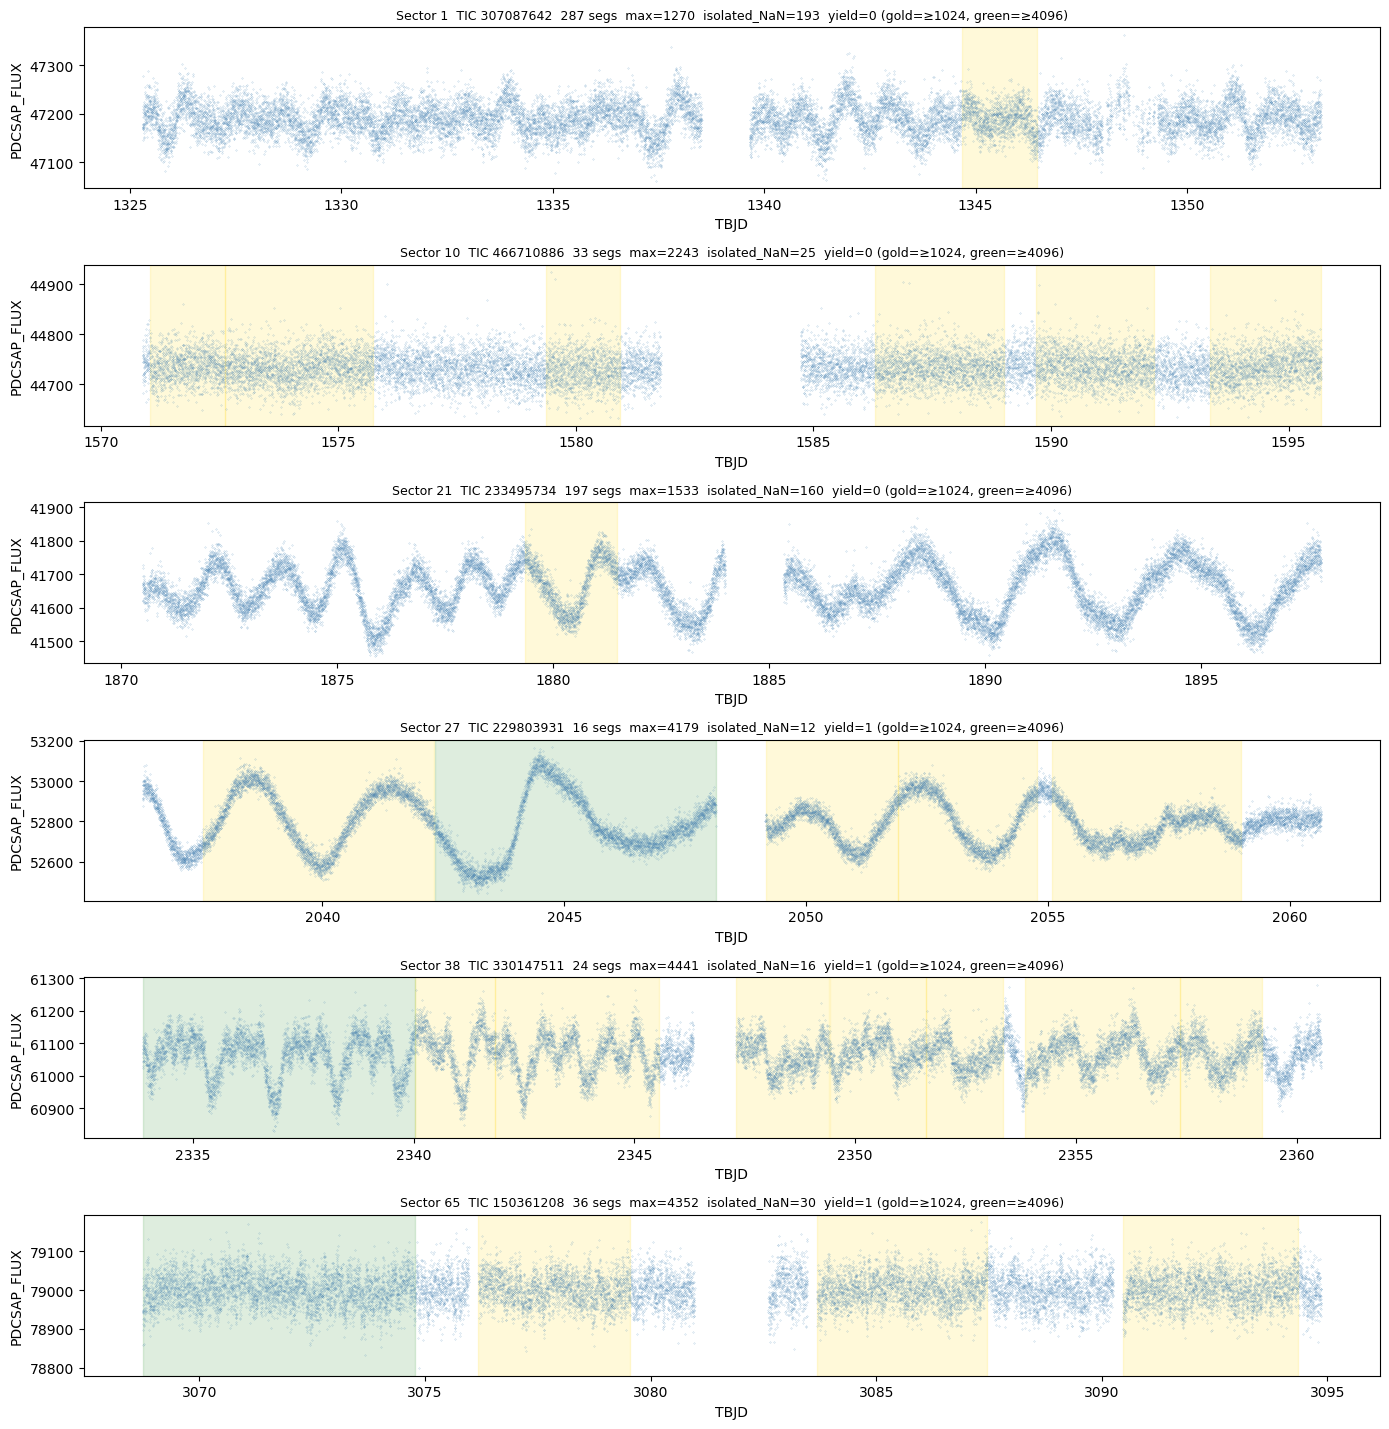

In [6]:
fig, axes = plt.subplots(len(sweep_results), 1, figsize=(14, 2.4 * len(sweep_results)), sharex=False)
if len(sweep_results) == 1: axes = [axes]

for ax, row in zip(axes, sweep_results):
    sector, tic = row['sector'], row['tic']
    path = DATA_TEMP / f'sweep_TIC{tic}_s{sector}.fits'
    t, f_ = bulk_read_fits(path)
    segs = find_segments(f_, gap_threshold=1)

    ax.plot(t, f_, '.', ms=0.4, color='steelblue', alpha=0.6, label='flux')
    # Shade segments >= 1024 cadences
    for s, e in segs:
        if e - s >= 1024:
            color = 'forestgreen' if e - s >= 4096 else 'gold'
            ax.axvspan(t[s], t[e-1], alpha=0.15, color=color)
    ax.set_title(
        f"Sector {sector}  TIC {tic}  "
        f"{row['n_segments']} segs  max={row['max_seg_len']}  "
        f"isolated_NaN={row['isolated_singletons']}  "
        f"yield={row['segs_ge_4096']} (gold=≥1024, green=≥4096)",
        fontsize=9,
    )
    ax.set_ylabel('PDCSAP_FLUX')
    ax.set_xlabel('TBJD')
plt.tight_layout()
plt.savefig(REPO / 'src' / 'notebooks' / 'bulk_sanity_sector_sweep.png', dpi=110, bbox_inches='tight')
plt.show()

## Test 5 — NaN run-length distribution

The hypothesis is that early sectors have many *isolated* single-cadence NaN values that fragment the light curve under `gap_threshold=1`.

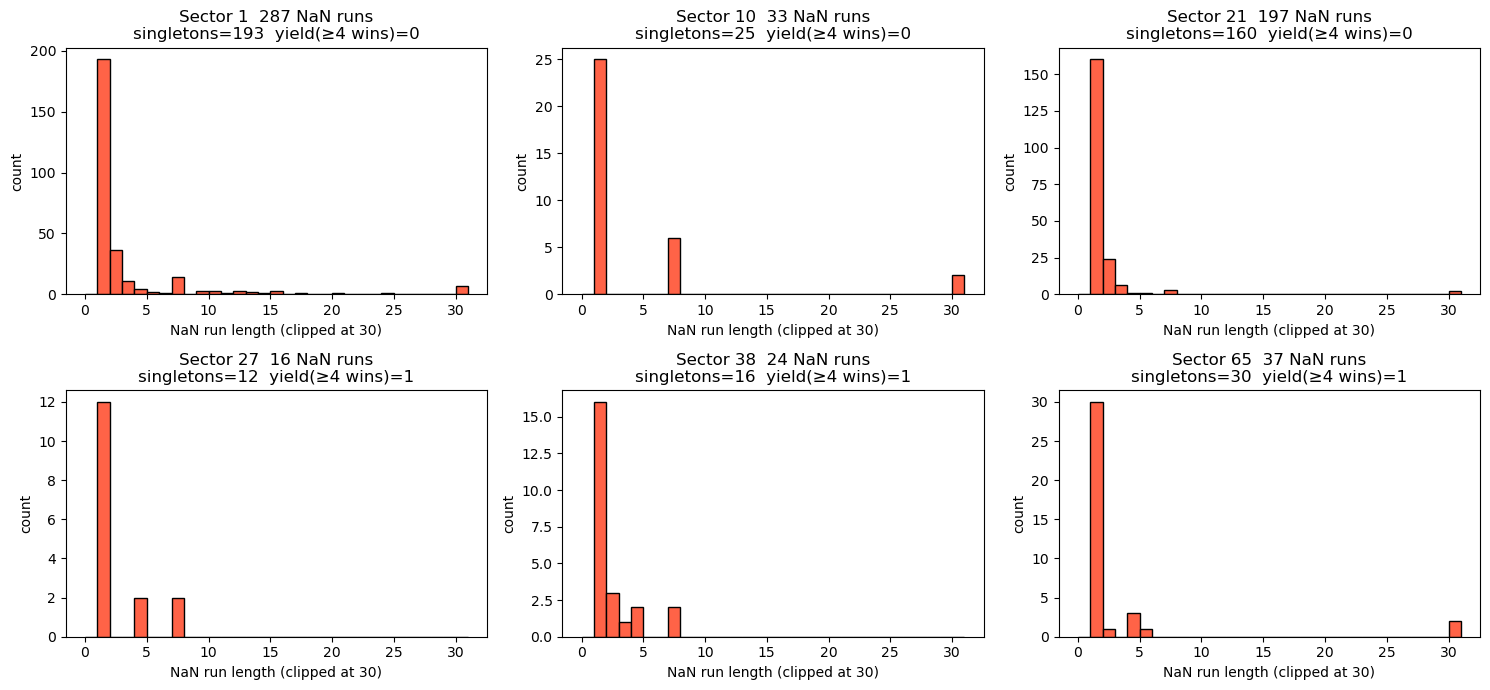

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=False)
axes = axes.flatten()
for ax, row in zip(axes, sweep_results):
    sector, tic = row['sector'], row['tic']
    path = DATA_TEMP / f'sweep_TIC{tic}_s{sector}.fits'
    _, f_ = bulk_read_fits(path)
    nan = np.isnan(f_)
    run_lengths = []
    in_run, run = False, 0
    for v in nan:
        if v: in_run = True; run += 1
        elif in_run:
            run_lengths.append(run); in_run = False; run = 0
    if in_run: run_lengths.append(run)
    run_lengths = np.array(run_lengths)
    if len(run_lengths):
        ax.hist(np.clip(run_lengths, 0, 30), bins=np.arange(0, 32), color='tomato', edgecolor='black')
    ax.set_title(f"Sector {sector}  {len(run_lengths)} NaN runs\n"
                 f"singletons={row['isolated_singletons']}  yield(≥4 wins)={row['segs_ge_4096']}")
    ax.set_xlabel('NaN run length (clipped at 30)')
    ax.set_ylabel('count')
plt.tight_layout()
plt.savefig(REPO / 'src' / 'notebooks' / 'bulk_sanity_nan_runs.png', dpi=110, bbox_inches='tight')
plt.show()

## Conclusion

Cells should print **PASS** twice (Tests 1 & 2). The sweep table (Test 3) should show:
- High `isolated_singletons` and `segs_ge_4096 = 0` for sectors 1-20
- Low `isolated_singletons` and `segs_ge_4096 > 0` for sectors ≥ 27

If both PASS lines print AND the sweep matches the predicted pattern, then `build_sequences_bulk.py` is byte-for-byte equivalent to the old pipeline, and early-sector zero-yield is intrinsic to the SPOC data quality.

## Post-processing: Full-corpus flux-outlier scan → inspect → delete

Three steps — run each cell in order:

1. **Scan** (next cell): find all NPZ files where `abs(windows).max() > 20.0`. Builds `outlier_files` list sorted worst-first.
2. **Inspect** (viewer cell): set `IDX` and re-run to view any file. Red = outlier windows. Note indices you want to preserve.
3. **Delete** (last cell): add any indices to `KEEP_INDICES` to spare, then set `DRY_RUN = False` to delete.

Re-run `inspect_sequences.ipynb` Section 1 after deletion to verify 0 flux-absmax failures remain.

In [ ]:
import concurrent.futures
from tqdm.auto import tqdm

SEQ_DIR    = REPO / "processed" / "sequences"
MAX_ABSMAX = 20.0

def _check_one(path):
    try:
        d = np.load(path)
        absmax = float(np.abs(d["windows"]).max())
        return (path, absmax) if absmax > MAX_ABSMAX else None
    except Exception:
        return None

all_npz = list(SEQ_DIR.glob("TIC*.npz"))
print(f"Total files: {len(all_npz):,}")

outlier_files = []  # list of (path, absmax), sorted worst-first
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as ex:
    for result in tqdm(ex.map(_check_one, all_npz), total=len(all_npz)):
        if result is not None:
            outlier_files.append(result)

outlier_files.sort(key=lambda x: -x[1])
print(f"\nOutlier files (flux_absmax > {MAX_ABSMAX}): {len(outlier_files):,}")
for i, (p, v) in enumerate(outlier_files[:10]):
    print(f"  [{i:3d}] {p.name}  absmax={v:.1f}")
if len(outlier_files) > 10:
    print(f"  ... and {len(outlier_files)-10} more  (indices 10–{len(outlier_files)-1})")

In [ ]:
# View an outlier file by index. Change IDX and re-run to inspect a different file.
# Note indices of files you want to keep; add them to KEEP_INDICES in the delete cell.

IDX = 0  # ← change this and re-run

if not outlier_files:
    print("Run the scan cell first.")
else:
    path, overall_absmax = outlier_files[IDX]
    d = np.load(path)
    wins = d["windows"][:, :, 0]  # (N, 1024)
    N = wins.shape[0]
    per_win_max = np.abs(wins).max(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(
        f"[{IDX} / {len(outlier_files)-1}]  {path.name}\n"
        f"TIC={int(d['tic_id'])}  sector={int(d['sector'])}  "
        f"seg={int(d['seg_idx'])}  run={int(d['run_idx'])}  "
        f"N={N} windows  overall_absmax={overall_absmax:.2f}",
        fontsize=10,
    )

    # Panel 1: all windows overlaid
    ax = axes[0]
    for i, w in enumerate(wins):
        color = "red" if per_win_max[i] > MAX_ABSMAX else "steelblue"
        alpha = 0.8 if per_win_max[i] > MAX_ABSMAX else 0.2
        ax.plot(w, color=color, alpha=alpha, lw=0.7)
    ax.set_title(f"All {N} windows  (red = abs-max > {MAX_ABSMAX})")
    ax.set_xlabel("time step")
    ax.set_ylabel("MAD-normalised flux")

    # Panel 2: per-window abs-max bar chart
    ax = axes[1]
    colors = ["red" if v > MAX_ABSMAX else "steelblue" for v in per_win_max]
    ax.bar(range(N), per_win_max, color=colors, edgecolor="none")
    ax.axhline(MAX_ABSMAX, color="red", ls="--", lw=1, label=f"threshold = {MAX_ABSMAX}")
    ax.set_title("Per-window abs-max")
    ax.set_xlabel("window index")
    ax.set_ylabel("abs-max")
    ax.legend(fontsize=8)

    # Panel 3: worst window detail
    worst_idx = int(per_win_max.argmax())
    ax = axes[2]
    ax.plot(wins[worst_idx], color="red", lw=1)
    ax.set_title(f"Worst window  (idx={worst_idx},  abs-max={per_win_max[worst_idx]:.2f})")
    ax.set_xlabel("time step")
    ax.set_ylabel("MAD-normalised flux")

    plt.tight_layout()
    plt.show()
    print(f"Per-window abs-max: {np.round(per_win_max, 2).tolist()}")

In [ ]:
# Delete outlier files found by the scan cell above.
# Add indices to KEEP_INDICES to preserve specific files after inspection.
# Set DRY_RUN = False when ready to delete.

DRY_RUN      = True   # ← set False to actually delete
KEEP_INDICES = set()  # ← e.g. {2, 5} to preserve outlier_files[2] and [5]

to_delete = [(i, p) for i, (p, _) in enumerate(outlier_files) if i not in KEEP_INDICES]
print(f"Files to delete: {len(to_delete):,}  (keeping {len(KEEP_INDICES)} exempt)")
for i, p in to_delete[:10]:
    print(f"  [{i}] {p.name}")
if len(to_delete) > 10:
    print(f"  ... and {len(to_delete)-10} more")

if not DRY_RUN:
    deleted = 0
    for _, p in to_delete:
        try:
            p.unlink(missing_ok=True)
            deleted += 1
        except OSError as e:
            print(f"  WARNING: could not delete {p.name}: {e}")
    remaining = len(list(SEQ_DIR.glob("TIC*.npz")))
    print(f"\nDeleted {deleted:,} files. Corpus now: {remaining:,}")
else:
    print("\nDRY_RUN=True — no files deleted")